# The IFT Correlated Field Model

**Building physical intuition for stochastic star formation histories**

This notebook introduces the Information Field Theory (IFT) correlated
field model that underpins `diffsed`. We build up the full SFH model
piece by piece — the power spectral density, the Gaussian process,
the smooth mean SFH, and the lognormal assembly — before ever touching
inference.  Think of this as the methods section of a paper, but
interactive.

By the end you will understand:
1. Why galaxy SFHs need stochastic fluctuations
2. How the PSD controls burstiness amplitude and timescale
3. How an FFT-based GP generates correlated fluctuations
4. How the full SFH is assembled with a lognormal correction
5. Why everything being JAX-differentiable matters

## Why burstiness matters

Star formation is not smooth. The scatter in the star-forming main
sequence ($\sim 0.3$ dex; Speagle et al. 2014) demands stochastic
variation on top of any smooth evolutionary track.  At high redshift,
UV-bright galaxies require bursty SFHs to explain their luminosity
functions (e.g., Sun et al. 2023).  Diagnostics like the
H$\alpha$-to-UV ratio directly probe burstiness on $\sim 10\,$Myr
timescales (Caplar & Tacchella 2019).

Traditional parametric models — exponentially declining ($\tau$-model),
delayed-$\tau$, or even double power laws — produce *deterministically
smooth* histories.  They cannot capture:

- **Duty cycles**: galaxies spending part of their life above/below
  the main sequence
- **Timescale-dependent variability**: feedback-driven fluctuations on
  $\sim 10\,$Myr vs. accretion-driven fluctuations on $\sim 300\,$Myr
- **Stochastic diversity**: two galaxies with identical masses having
  very different recent SFHs

The IFT correlated field model solves this by adding a *Gaussian
process* — controlled by a power spectral density — on top of a smooth
backbone.  The PSD parameters ($\sigma$, $\tau$) become physically
interpretable burstiness priors.

W0315 02:04:17.335016 4329761 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


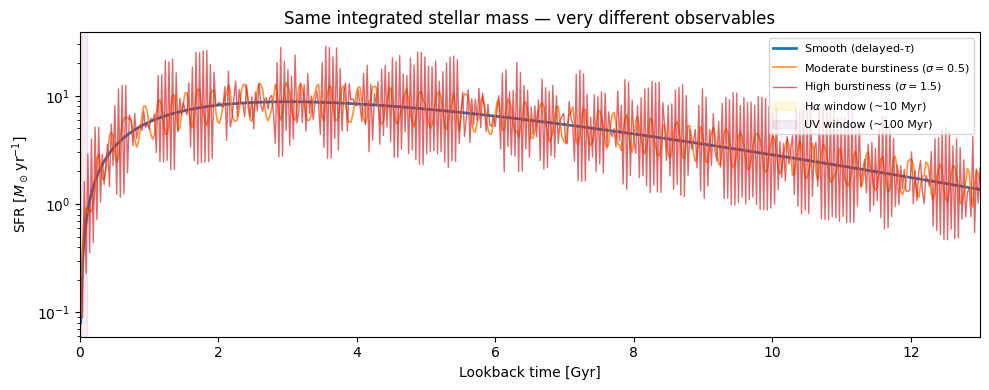

In [1]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import numpy as np

from diffsed.models.sfh.mean_sfh import double_powerlaw, delayed_tau

# --- Three SFHs with the same stellar mass but different burstiness ---
t_lookback = jnp.linspace(0.01e9, 13.0e9, 500)  # yr

# 1. Smooth parametric (delayed-tau)
sfr_smooth = delayed_tau(t_lookback, tau=3e9, norm=8e-9)

# 2. Moderately bursty (hand-crafted sinusoidal fluctuations for illustration)
np.random.seed(12)
phase = np.cumsum(np.random.normal(0, 0.3, len(t_lookback)))
sfr_moderate = sfr_smooth * jnp.exp(0.4 * jnp.sin(2 * jnp.pi * t_lookback / 200e6 + phase[:len(t_lookback)]))

# 3. Highly bursty
sfr_bursty = sfr_smooth * jnp.exp(1.2 * jnp.sin(2 * jnp.pi * t_lookback / 50e6 + phase[:len(t_lookback)]))

fig, ax = plt.subplots(figsize=(10, 4))
t_gyr = t_lookback / 1e9
ax.plot(t_gyr, sfr_smooth, lw=2, label="Smooth (delayed-$\\tau$)", color="C0")
ax.plot(t_gyr, sfr_moderate, lw=1.2, alpha=0.85, label="Moderate burstiness ($\\sigma=0.5$)", color="C1")
ax.plot(t_gyr, sfr_bursty, lw=1.0, alpha=0.7, label="High burstiness ($\\sigma=1.5$)", color="C3")

ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel("SFR [$M_\\odot\\,\\mathrm{yr}^{-1}$]")
ax.set_title("Same stellar mass, different burstiness")
ax.legend(loc="upper right", fontsize=9)
ax.set_yscale("log")
ax.set_xlim(0, 13)

# Annotate diagnostic windows
ax.axvspan(0, 0.01, alpha=0.15, color="gold", label="H$\\alpha$ window (~10 Myr)")
ax.axvspan(0, 0.1, alpha=0.08, color="purple", label="UV window (~100 Myr)")
ax.legend(loc="upper right", fontsize=8)
ax.set_title("Same integrated stellar mass — very different observables")
plt.tight_layout()
plt.show()

## The SFH decomposition

The key equation of the correlated field model:

$$
\ln \mathrm{SFR}(t) \;=\; \ln\,\overline{\mathrm{SFR}}(t)
    \;-\; \tfrac{K(0)}{2} \;+\; x(t)
$$

Three pieces:

| Component | Symbol | Role |
|-----------|--------|------|
| Smooth backbone | $\overline{\mathrm{SFR}}(t)$ | Long-term evolutionary trend (double power law) |
| Lognormal correction | $-K(0)/2$ | Ensures $\langle e^{x}\rangle = 1$ — prevents bursty models from overproducing stars |
| Stochastic field | $x(t) \sim \mathcal{GP}(0, K)$ | Correlated fluctuations governed by the PSD |

**Analogy**: think of $\overline{\mathrm{SFR}}$ as the *climate* (long-term
average) and $x(t)$ as the *weather* (stochastic day-to-day variation).
The PSD determines whether your galaxy lives in the tropics (steady
rain) or the desert (rare flash floods).

In [2]:
# --- Setup: imports and grid ---
from diffsed.models.sfh.psd_models import psd_drw, drw_acf, drw_variance
from diffsed.models.sfh.gp_sfh import (
    make_log_age_grid, compute_sqrt_power_drw, gp_from_xi,
    generate_gp_fourier, generate_gp_batch,
)
from diffsed.models.sfh.mean_sfh import double_powerlaw

N_GRID = 128
log_ages = make_log_age_grid(n_grid=N_GRID)
d_log_age = float(log_ages[1] - log_ages[0])
ages_yr = 10**log_ages
ages_gyr = ages_yr / 1e9

print(f"Grid: {N_GRID} points, log(age/yr) = {float(log_ages[0]):.2f} to {float(log_ages[-1]):.2f}")
print(f"Spacing: {d_log_age:.4f} dex")
print(f"Time range: {float(ages_gyr[0]):.3f} Myr to {float(ages_gyr[-1]):.1f} Gyr")

Grid: 128 points, log(age/yr) = 6.00 to 10.14
Spacing: 0.0326 dex
Time range: 0.001 Myr to 13.8 Gyr


## The Power Spectral Density

The PSD controls **how bursty** and **on what timescale** the SFH
fluctuates.  We adopt a damped random walk (DRW / Lorentzian):

$$
P(\omega) = \frac{\sigma^2 \,\tau}{1 + (\tau\,\omega)^2}
$$

Two parameters fully specify the stochastic behavior:

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| Amplitude | $\sigma$ | How bursty (dex of SFR scatter) |
| Timescale | $\tau$ | How long bursts last (yr) |

The DRW PSD has a simple analytic autocorrelation function
(Wiener--Khinchin theorem):

$$
K(\Delta t) = \frac{\sigma^2}{2}\,\exp\!\left(-\frac{|\Delta t|}{\tau}\right)
$$

with stationary variance $K(0) = \sigma^2/2$.

### Physical timescale guide

| $\tau$ | Physical process | Example |
|--------|-----------------|---------|
| 5--10 Myr | Stellar winds + supernovae | Individual OB association lifecycle |
| 20--50 Myr | Superbubble feedback | Collective SNe clearing gas, then re-accretion |
| 100--300 Myr | Gas accretion cycles | Cosmic filament inflow modulation |
| 500+ Myr | Mergers / interactions | Major merger–induced starburst + quenching |

*If $\tau = 50\,$Myr, a burst lasts about the lifetime of a
superbubble — the collective effect of $\sim 10^3$ supernovae
clearing and re-filling a $\sim\,$kpc-scale cavity.*

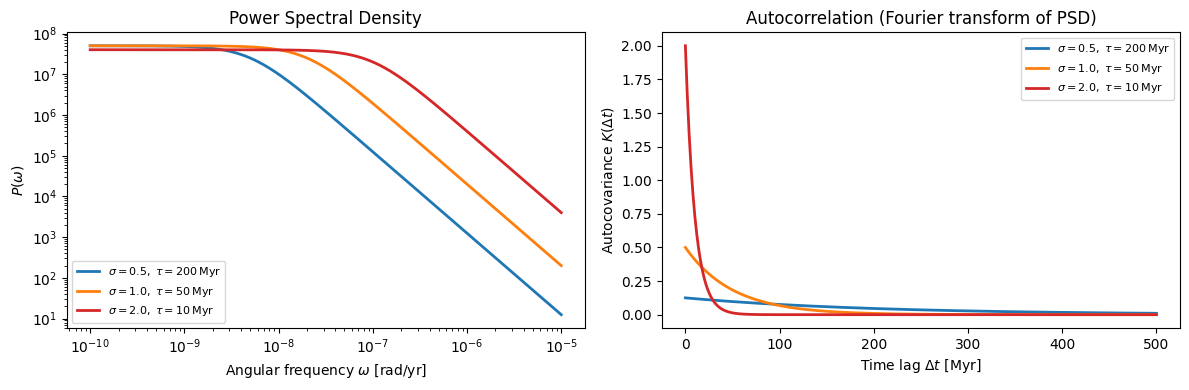

In [3]:
# --- PSD and autocorrelation for three (sigma, tau) combos ---
omega = jnp.logspace(-10, -5, 500)  # rad/yr
delta_t = jnp.linspace(0, 500e6, 500)  # yr

configs = [
    (0.5, 200e6, "C0", "$\\sigma=0.5,\\;\\tau=200\\,$Myr"),
    (1.0, 50e6,  "C1", "$\\sigma=1.0,\\;\\tau=50\\,$Myr"),
    (2.0, 10e6,  "C3", "$\\sigma=2.0,\\;\\tau=10\\,$Myr"),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for sigma, tau, color, label in configs:
    psd_vals = psd_drw(omega, sigma, tau)
    acf_vals = drw_acf(delta_t, sigma, tau)
    ax1.loglog(omega, psd_vals, color=color, lw=2, label=label)
    ax2.plot(delta_t / 1e6, acf_vals, color=color, lw=2, label=label)

ax1.set_xlabel("Angular frequency $\\omega$ [rad/yr]")
ax1.set_ylabel("$P(\\omega)$")
ax1.set_title("Power Spectral Density")
ax1.legend(fontsize=8)

ax2.set_xlabel("Time lag $\\Delta t$ [Myr]")
ax2.set_ylabel("Autocovariance $K(\\Delta t)$")
ax2.set_title("Autocorrelation (Fourier transform of PSD)")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## From PSD to Stochastic SFH

The correlated field model generates GP realizations via an FFT recipe:

1. Draw a standardized latent vector: $\boldsymbol{\xi} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$
2. Fourier transform: $\hat{\boldsymbol{\xi}} = \mathrm{FFT}(\boldsymbol{\xi})$
3. Multiply by amplitude operator: $\hat{\mathbf{s}} = \sqrt{P(\omega)}\;\hat{\boldsymbol{\xi}}$
4. Inverse transform: $\mathbf{x} = \mathrm{IFFT}(\hat{\mathbf{s}})$

The resulting field $x(t)$ inherits the correlation structure encoded in
$P(\omega)$.  This is the core of the NIFTy / IFT approach
(Ensslin et al. 2009): the latent vector $\boldsymbol{\xi}$ lives in a
*standardized* space where the prior is simply $\mathcal{N}(0, I)$,
making it ideal for gradient-based samplers.

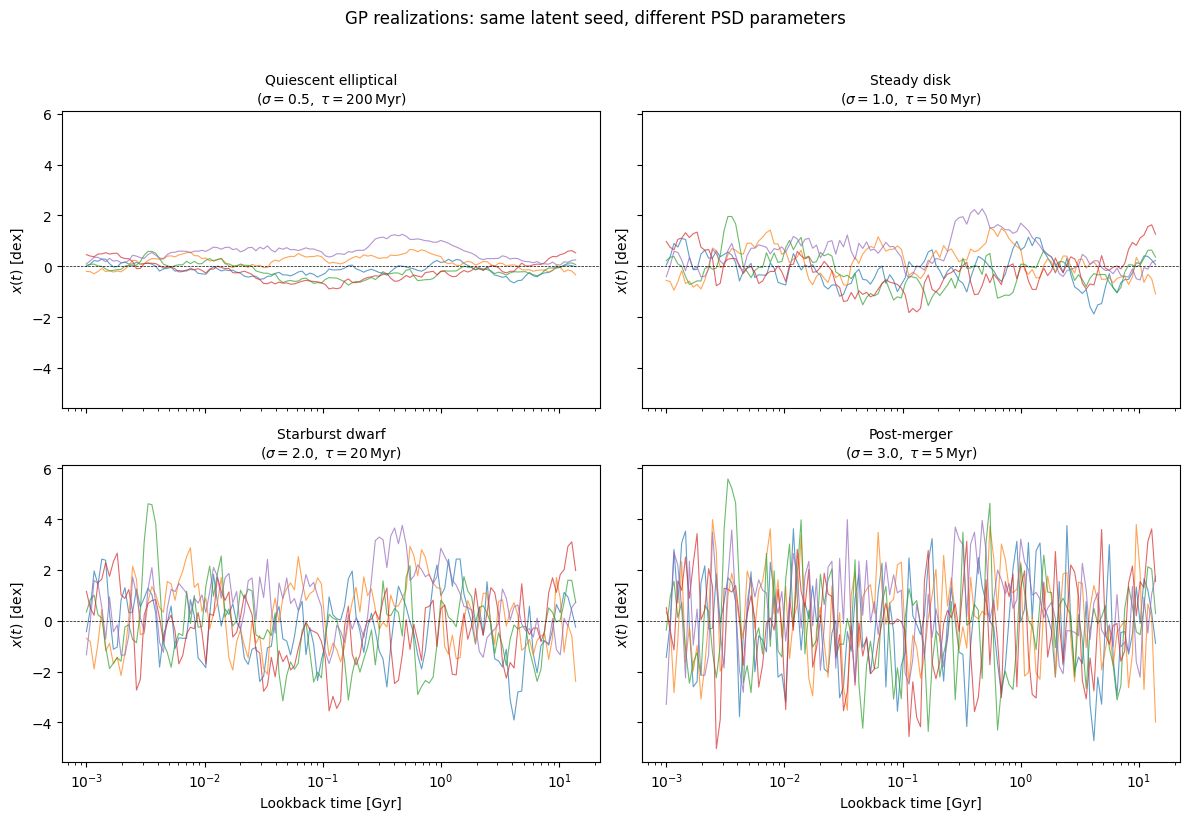

In [4]:
# --- GP realizations across the burstiness plane ---
regimes = [
    (0.5, 200e6, "Quiescent elliptical\n($\\sigma=0.5,\\;\\tau=200\\,$Myr)"),
    (1.0, 50e6,  "Steady disk\n($\\sigma=1.0,\\;\\tau=50\\,$Myr)"),
    (2.0, 20e6,  "Starburst dwarf\n($\\sigma=2.0,\\;\\tau=20\\,$Myr)"),
    (3.0, 5e6,   "Post-merger\n($\\sigma=3.0,\\;\\tau=5\\,$Myr)"),
]

n_realizations = 5
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for ax, (sigma, tau, title) in zip(axes.ravel(), regimes):
    sqrt_power = compute_sqrt_power_drw(N_GRID, d_log_age, sigma, tau)
    key = jax.random.PRNGKey(42)
    gp_batch = generate_gp_batch(key, sqrt_power, N_GRID, n_realizations)

    for i in range(n_realizations):
        ax.plot(ages_gyr, gp_batch[i], lw=0.8, alpha=0.7)
    ax.axhline(0, color="k", ls="--", lw=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("$x(t)$ [dex]")

for ax in axes[1]:
    ax.set_xlabel("Lookback time [Gyr]")
axes[0, 0].set_xscale("log")
fig.suptitle("GP realizations: same latent seed, different PSD parameters", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## The Mean Star Formation History

The smooth backbone is a double power law (Carnall et al. 2018;
Behroozi et al. 2013):

$$
\overline{\mathrm{SFR}}(t) = \frac{A}{\left(\frac{t}{\tau_\mathrm{sfh}}\right)^\alpha
+ \left(\frac{t}{\tau_\mathrm{sfh}}\right)^{-\beta}}
$$

Four parameters control the shape:

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| Rise slope | $\beta$ | Steepness of SFR increase (in cosmic time) |
| Decline slope | $\alpha$ | Steepness of SFR decrease after peak |
| Peak time | $\tau_\mathrm{sfh}$ | Approximate epoch of peak SFR (yr) |
| Normalization | $A$ | Peak SFR amplitude ($M_\odot\,\mathrm{yr}^{-1}$) |

**Convention**: `double_powerlaw` takes **lookback time** $t$ in years.
In lookback time, $\alpha$ controls the right side (early universe,
large lookback) and $\beta$ controls the left side (near present).

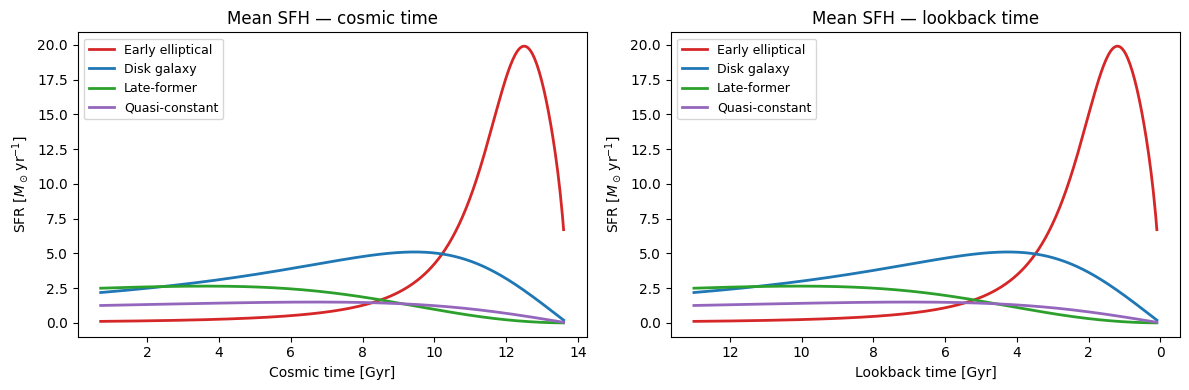

In [5]:
# --- Four SFH archetypes ---
t_lb = jnp.linspace(0.1e9, 13.0e9, 400)  # lookback time in yr
t_cosmic = 13.7e9 - t_lb  # cosmic time

archetypes = [
    dict(alpha=3.0, beta=0.5, tau=2e9,  norm=30.0, label="Early elliptical", color="C3"),
    dict(alpha=1.5, beta=1.0, tau=5e9,  norm=10.0, label="Disk galaxy",      color="C0"),
    dict(alpha=1.0, beta=2.0, tau=8e9,  norm=5.0,  label="Late-former",      color="C2"),
    dict(alpha=1.0, beta=1.0, tau=7e9,  norm=3.0,  label="Quasi-constant",   color="C4"),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for p in archetypes:
    sfr = double_powerlaw(t_lb, p["alpha"], p["beta"], p["tau"], p["norm"])
    ax1.plot(t_cosmic / 1e9, sfr, lw=2, color=p["color"], label=p["label"])
    ax2.plot(t_lb / 1e9, sfr, lw=2, color=p["color"], label=p["label"])

ax1.set_xlabel("Cosmic time [Gyr]")
ax1.set_ylabel("SFR [$M_\\odot\\,\\mathrm{yr}^{-1}$]")
ax1.set_title("Mean SFH — cosmic time")
ax1.legend(fontsize=9)

ax2.set_xlabel("Lookback time [Gyr]")
ax2.set_ylabel("SFR [$M_\\odot\\,\\mathrm{yr}^{-1}$]")
ax2.set_title("Mean SFH — lookback time")
ax2.legend(fontsize=9)
ax2.invert_xaxis()

plt.tight_layout()
plt.show()

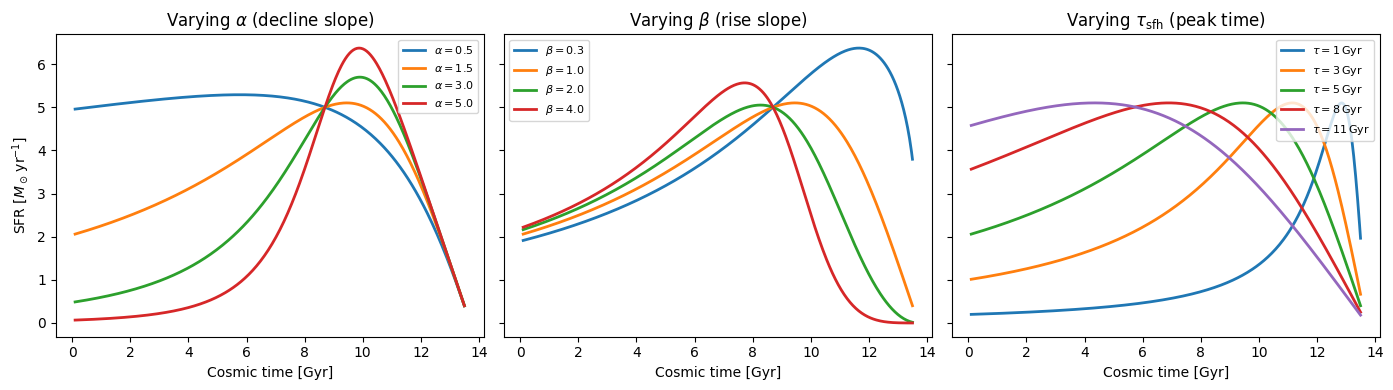

In [6]:
# --- Effect of varying alpha, beta, tau independently ---
t_cosmic = jnp.linspace(0.1e9, 13.5e9, 400)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

# Panel 1: vary alpha
for alpha in [0.5, 1.5, 3.0, 5.0]:
    sfr = double_powerlaw(13.7e9 - t_cosmic, alpha=alpha, beta=1.0, tau=5e9, norm=10.0)
    axes[0].plot(t_cosmic / 1e9, sfr, lw=2, label=f"$\\alpha={alpha}$")
axes[0].set_title("Varying $\\alpha$ (decline slope)")
axes[0].legend(fontsize=8)

# Panel 2: vary beta
for beta in [0.3, 1.0, 2.0, 4.0]:
    sfr = double_powerlaw(13.7e9 - t_cosmic, alpha=1.5, beta=beta, tau=5e9, norm=10.0)
    axes[1].plot(t_cosmic / 1e9, sfr, lw=2, label=f"$\\beta={beta}$")
axes[1].set_title("Varying $\\beta$ (rise slope)")
axes[1].legend(fontsize=8)

# Panel 3: vary tau
for tau_gyr in [1, 3, 5, 8, 11]:
    sfr = double_powerlaw(13.7e9 - t_cosmic, alpha=1.5, beta=1.0, tau=tau_gyr * 1e9, norm=10.0)
    axes[2].plot(t_cosmic / 1e9, sfr, lw=2, label=f"$\\tau={tau_gyr}\\,$Gyr")
axes[2].set_title("Varying $\\tau_\\mathrm{sfh}$ (peak time)")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel("Cosmic time [Gyr]")
axes[0].set_ylabel("SFR [$M_\\odot\\,\\mathrm{yr}^{-1}$]")
plt.tight_layout()
plt.show()

## Assembling the Full SFH

Now we combine the pieces. Step by step:

1. **Mean SFH**: $\overline{\mathrm{SFR}}(t)$ from the double power law
2. **GP realization**: $x(t) = \mathrm{IFFT}\!\left(\sqrt{P}\;\hat{\xi}\right)$
3. **Lognormal correction**: subtract $K(0)/2$ to ensure
   $\langle e^{x(t)}\rangle = 1$
4. **Full SFH**: $\mathrm{SFR}(t) = \overline{\mathrm{SFR}}(t) \cdot
   \exp\!\left[x(t) - K(0)/2\right]$

The correction $-K(0)/2$ is critical.  Without it, the expectation value
$\langle e^x \rangle = e^{K(0)/2} > 1$ (lognormal bias), and bursty
models would systematically **overproduce** stars relative to the smooth
backbone.

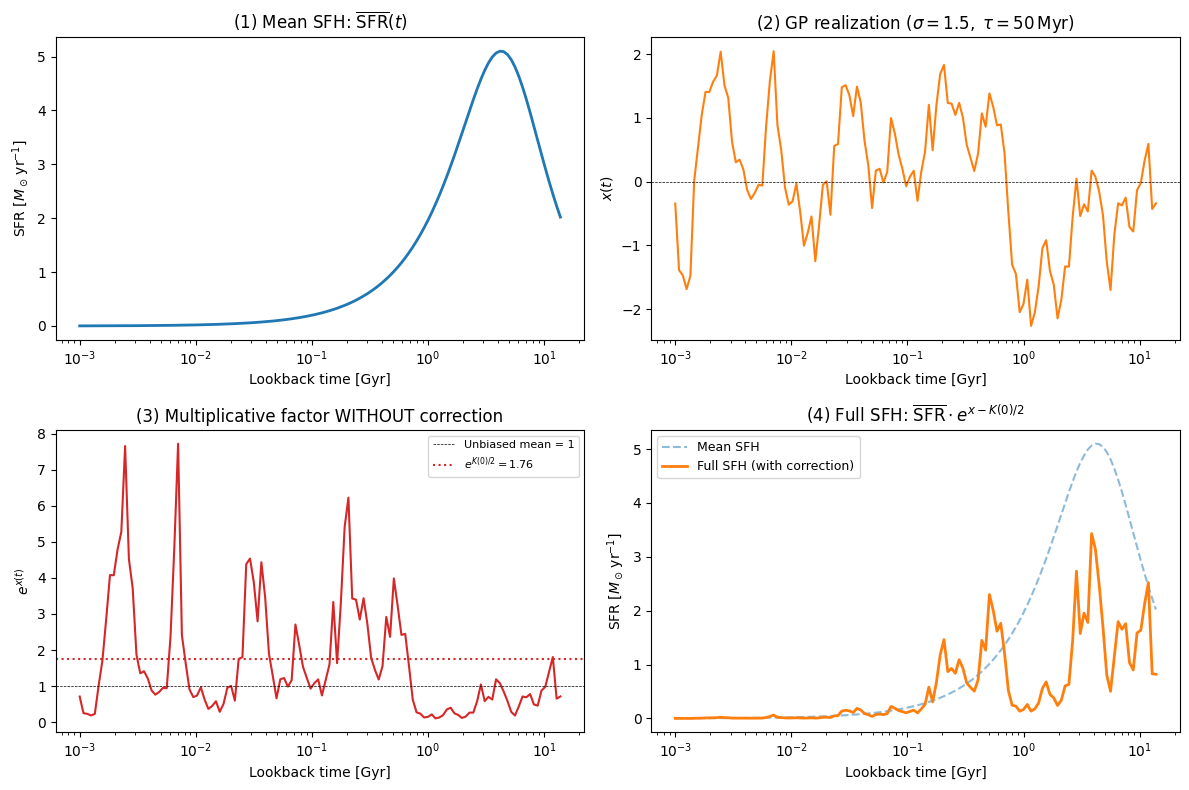

In [7]:
# --- Step-by-step SFH assembly ---
sigma_ps, tau_ps = 1.5, 50e6  # yr
sqrt_power = compute_sqrt_power_drw(N_GRID, d_log_age, sigma_ps, tau_ps)
variance = drw_variance(sigma_ps)

key = jax.random.PRNGKey(7)
xi = jax.random.normal(key, (N_GRID,))
gp = gp_from_xi(xi, sqrt_power, N_GRID)

# Mean SFH on the log-age grid (lookback time)
sfr_mean = double_powerlaw(ages_yr, alpha=1.5, beta=1.0, tau=5e9, norm=10.0)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Panel 1: Mean SFH
axes[0, 0].plot(ages_gyr, sfr_mean, "C0", lw=2)
axes[0, 0].set_ylabel("SFR [$M_\\odot\\,\\mathrm{yr}^{-1}$]")
axes[0, 0].set_title("(1) Mean SFH: $\\overline{\\mathrm{SFR}}(t)$")
axes[0, 0].set_xscale("log")

# Panel 2: GP realization
axes[0, 1].plot(ages_gyr, gp, "C1", lw=1.5)
axes[0, 1].axhline(0, color="k", ls="--", lw=0.5)
axes[0, 1].set_ylabel("$x(t)$")
axes[0, 1].set_title(f"(2) GP realization ($\\sigma={sigma_ps},\\;\\tau={tau_ps/1e6:.0f}\\,$Myr)")
axes[0, 1].set_xscale("log")

# Panel 3: exp(GP) WITHOUT correction — show bias
exp_gp_no_corr = jnp.exp(gp)
axes[1, 0].plot(ages_gyr, exp_gp_no_corr, "C3", lw=1.5)
axes[1, 0].axhline(1.0, color="k", ls="--", lw=0.5, label="Unbiased mean = 1")
axes[1, 0].axhline(float(jnp.exp(0.5 * variance)), color="C3", ls=":",
                    lw=1.5, label=f"$e^{{K(0)/2}} = {float(jnp.exp(0.5 * variance)):.2f}$")
axes[1, 0].set_ylabel("$e^{x(t)}$")
axes[1, 0].set_title("(3) Multiplicative factor WITHOUT correction")
axes[1, 0].legend(fontsize=8)
axes[1, 0].set_xscale("log")

# Panel 4: Full SFH with correction
correction = -0.5 * variance
sfr_full = sfr_mean * jnp.exp(gp + correction)
axes[1, 1].plot(ages_gyr, sfr_mean, "C0", lw=1.5, ls="--", alpha=0.5, label="Mean SFH")
axes[1, 1].plot(ages_gyr, sfr_full, "C1", lw=2, label="Full SFH (with correction)")
axes[1, 1].set_ylabel("SFR [$M_\\odot\\,\\mathrm{yr}^{-1}$]")
axes[1, 1].set_title("(4) Full SFH: $\\overline{\\mathrm{SFR}} \\cdot e^{x - K(0)/2}$")
axes[1, 1].legend(fontsize=9)
axes[1, 1].set_xscale("log")

for ax in axes.ravel():
    ax.set_xlabel("Lookback time [Gyr]")
plt.tight_layout()
plt.show()

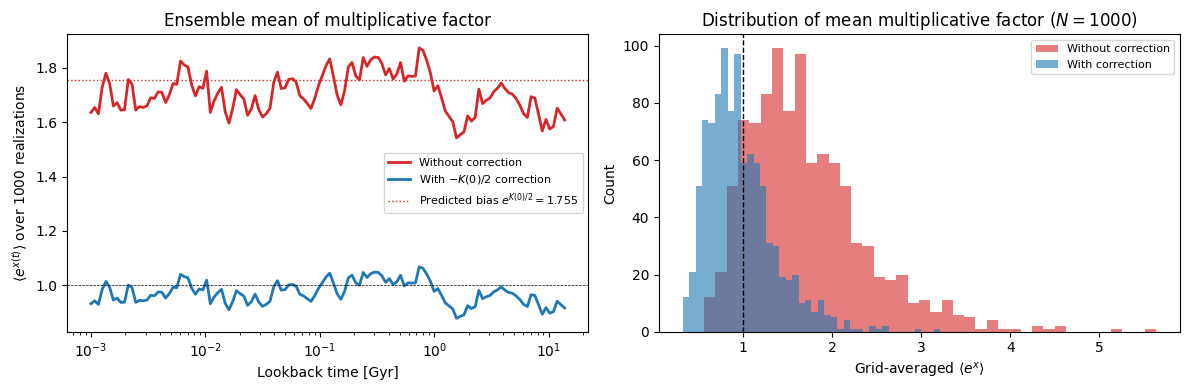

In [8]:
# --- Lognormal bias: ensemble demonstration ---
sigma_ps = 1.5
variance = drw_variance(sigma_ps)
sqrt_power = compute_sqrt_power_drw(N_GRID, d_log_age, sigma_ps, 50e6)

key = jax.random.PRNGKey(0)
n_samples = 1000
gp_ensemble = generate_gp_batch(key, sqrt_power, N_GRID, n_samples)

# Without correction: E[exp(x)] should be exp(K(0)/2) > 1
exp_no_corr = jnp.exp(gp_ensemble)
mean_no_corr = jnp.mean(exp_no_corr, axis=0)

# With correction: E[exp(x - K(0)/2)] should be ~1
exp_with_corr = jnp.exp(gp_ensemble - 0.5 * variance)
mean_with_corr = jnp.mean(exp_with_corr, axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: spatial mean across grid
ax1.plot(ages_gyr, mean_no_corr, "C3", lw=2, label="Without correction")
ax1.plot(ages_gyr, mean_with_corr, "C0", lw=2, label="With $-K(0)/2$ correction")
ax1.axhline(1.0, color="k", ls="--", lw=0.5)
ax1.axhline(float(jnp.exp(0.5 * variance)), color="C3", ls=":", lw=1,
            label=f"Predicted bias $e^{{K(0)/2}} = {float(jnp.exp(0.5 * variance)):.3f}$")
ax1.set_xlabel("Lookback time [Gyr]")
ax1.set_ylabel("$\\langle e^{x(t)} \\rangle$ over 1000 realizations")
ax1.set_title("Ensemble mean of multiplicative factor")
ax1.legend(fontsize=8)
ax1.set_xscale("log")

# Right: histogram of grid-averaged exp(x) per realization
grid_means_no = jnp.mean(exp_no_corr, axis=1)
grid_means_yes = jnp.mean(exp_with_corr, axis=1)
ax2.hist(np.array(grid_means_no), bins=40, alpha=0.6, color="C3", label="Without correction")
ax2.hist(np.array(grid_means_yes), bins=40, alpha=0.6, color="C0", label="With correction")
ax2.axvline(1.0, color="k", ls="--", lw=1)
ax2.set_xlabel("Grid-averaged $\\langle e^x \\rangle$")
ax2.set_ylabel("Count")
ax2.set_title(f"Distribution of mean multiplicative factor ($N={n_samples}$)")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## The Burstiness Plane

The two PSD parameters $\sigma$ and $\tau$ define a 2D space of galaxy
variability — the **burstiness plane**.

- **$\sigma$** (vertical axis): controls the *amplitude* of fluctuations.
  $\sigma = 0.5$ gives gentle ripples; $\sigma = 3$ gives order-of-magnitude
  bursts and quenching episodes.
- **$\tau$** (horizontal axis): controls the *timescale*.
  $\tau = 10\,$Myr means rapid flickering; $\tau = 200\,$Myr means slow,
  secular oscillations.

Different regions of this plane correspond to physically distinct galaxy
populations, as we now demonstrate.

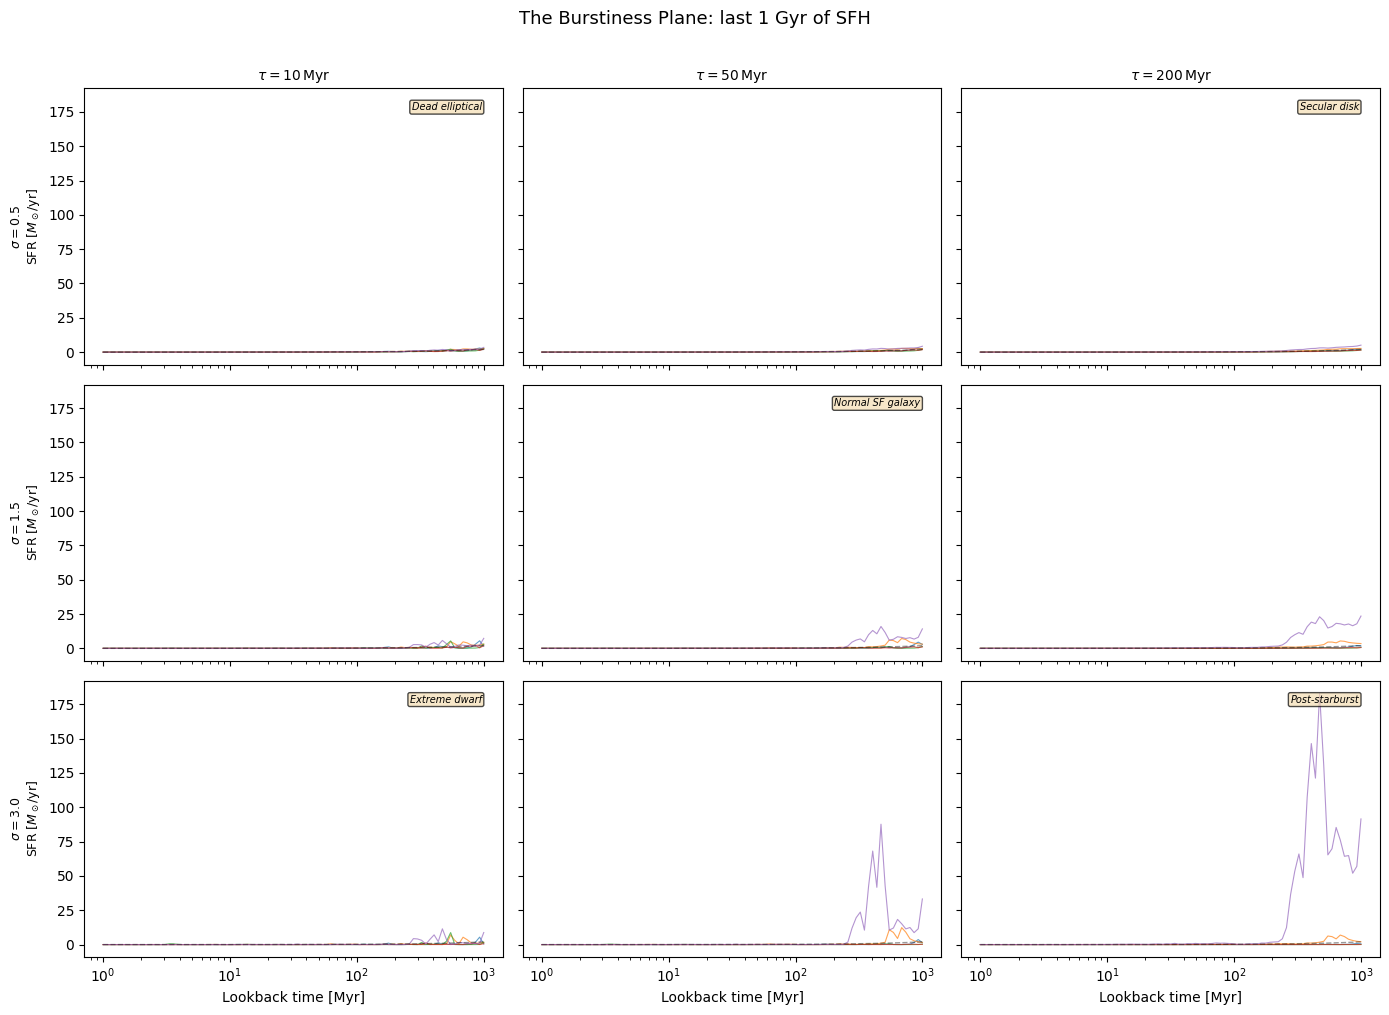

In [9]:
# --- Burstiness plane: 3x3 grid of (sigma, tau) ---
sigma_vals = [0.5, 1.5, 3.0]
tau_vals = [10e6, 50e6, 200e6]
tau_labels = ["10", "50", "200"]
n_real = 5

# Galaxy type annotations
annotations = {
    (0, 0): "Dead elliptical",
    (0, 2): "Secular disk",
    (1, 1): "Normal SF galaxy",
    (2, 0): "Extreme dwarf",
    (2, 2): "Post-starburst",
}

fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True, sharey=True)

# Use log-age grid for last 1 Gyr: select lookback < 1 Gyr
mask = ages_yr <= 1e9
t_plot = ages_yr[mask] / 1e6  # Myr

for i, sigma in enumerate(sigma_vals):
    for j, tau in enumerate(tau_vals):
        ax = axes[i, j]
        sqrt_power = compute_sqrt_power_drw(N_GRID, d_log_age, sigma, tau)
        variance = drw_variance(sigma)
        correction = -0.5 * variance
        sfr_mean_grid = double_powerlaw(ages_yr, alpha=1.5, beta=1.0, tau=5e9, norm=10.0)

        key = jax.random.PRNGKey(42)
        gps = generate_gp_batch(key, sqrt_power, N_GRID, n_real)

        for k in range(n_real):
            sfr = sfr_mean_grid * jnp.exp(gps[k] + correction)
            ax.plot(t_plot, sfr[mask], lw=0.8, alpha=0.7)

        ax.plot(t_plot, sfr_mean_grid[mask], "k--", lw=1, alpha=0.4)

        if (i, j) in annotations:
            ax.text(0.95, 0.95, annotations[(i, j)], transform=ax.transAxes,
                    ha="right", va="top", fontsize=7, style="italic",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="wheat", alpha=0.7))

        if i == 0:
            ax.set_title(f"$\\tau = {tau_labels[j]}\\,$Myr", fontsize=10)
        if j == 0:
            ax.set_ylabel(f"$\\sigma = {sigma}$\nSFR [$M_\\odot$/yr]", fontsize=9)

for ax in axes[2]:
    ax.set_xlabel("Lookback time [Myr]")
axes[0, 0].set_xscale("log")

fig.suptitle("The Burstiness Plane: last 1 Gyr of SFH", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

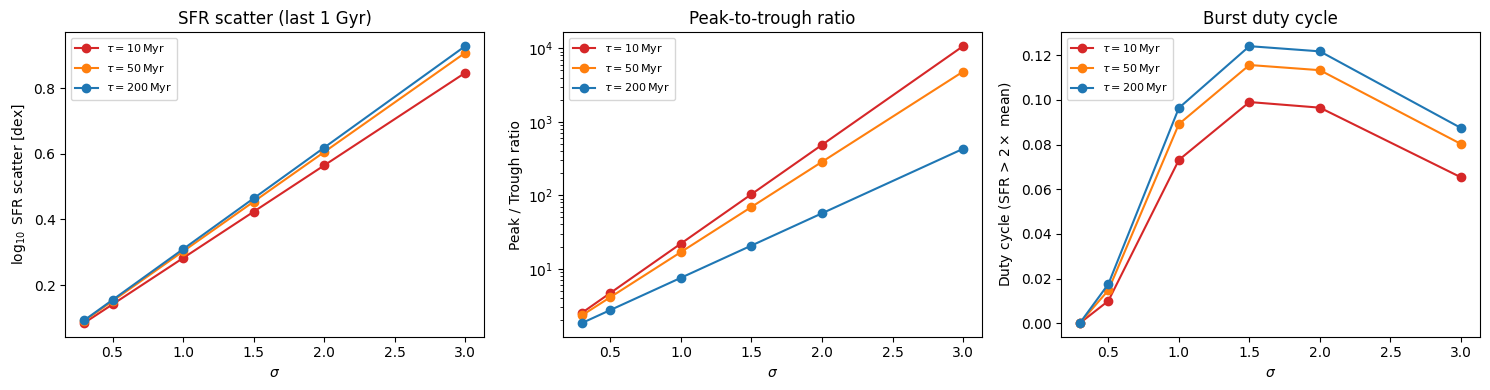

In [10]:
# --- Ensemble properties: sSFR scatter, peak-to-trough, duty cycle ---
sigma_scan = jnp.array([0.3, 0.5, 1.0, 1.5, 2.0, 3.0])
tau_scan = jnp.array([10e6, 50e6, 200e6])
n_mc = 500

results = []

for tau in tau_scan:
    for sigma in sigma_scan:
        sqrt_power = compute_sqrt_power_drw(N_GRID, d_log_age, float(sigma), float(tau))
        variance = drw_variance(float(sigma))
        correction = -0.5 * variance

        key = jax.random.PRNGKey(99)
        gps = generate_gp_batch(key, sqrt_power, N_GRID, n_mc)
        sfr_factors = jnp.exp(gps + correction)  # multiplicative factors

        # Metrics on last 1 Gyr
        sfr_recent = sfr_factors[:, mask]

        # sSFR scatter (std of log10 SFR)
        log_scatter = float(jnp.std(jnp.log10(sfr_recent)))

        # Peak-to-trough ratio (median across realizations)
        ratios = jnp.max(sfr_recent, axis=1) / jnp.clip(jnp.min(sfr_recent, axis=1), 1e-10)
        median_ratio = float(jnp.median(ratios))

        # Duty cycle: fraction of time above 2x mean
        duty = float(jnp.mean(sfr_recent > 2.0))

        results.append(dict(sigma=float(sigma), tau=float(tau),
                            scatter=log_scatter, ratio=median_ratio, duty=duty))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
tau_colors = {10e6: "C3", 50e6: "C1", 200e6: "C0"}
tau_names = {10e6: "$\\tau=10\\,$Myr", 50e6: "$\\tau=50\\,$Myr", 200e6: "$\\tau=200\\,$Myr"}

for tau in tau_scan:
    subset = [r for r in results if r["tau"] == float(tau)]
    sigmas = [r["sigma"] for r in subset]
    color = tau_colors[float(tau)]
    label = tau_names[float(tau)]

    axes[0].plot(sigmas, [r["scatter"] for r in subset], "o-", color=color, label=label)
    axes[1].plot(sigmas, [r["ratio"] for r in subset], "o-", color=color, label=label)
    axes[2].plot(sigmas, [r["duty"] for r in subset], "o-", color=color, label=label)

axes[0].set_ylabel("$\\log_{10}$ SFR scatter [dex]")
axes[0].set_title("SFR scatter (last 1 Gyr)")
axes[1].set_ylabel("Peak / Trough ratio")
axes[1].set_title("Peak-to-trough ratio")
axes[1].set_yscale("log")
axes[2].set_ylabel("Duty cycle (SFR > $2 \\times$ mean)")
axes[2].set_title("Burst duty cycle")

for ax in axes:
    ax.set_xlabel("$\\sigma$")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Parameter summary

| # | High-level name | Internal name | Meaning | Units | Typical range |
|---|----------------|---------------|---------|-------|---------------|
| 1 | `sfh_alpha` | `alpha` | Decline slope (cosmic time) | — | 0.5–5 |
| 2 | `sfh_beta` | `beta` | Rise slope (cosmic time) | — | 0.3–3 |
| 3 | `sfh_tau_peak_gyr` | `tau_sfh` | Peak SFR epoch | Gyr (→ yr internally) | 1–11 |
| 4 | `sfh_norm` | `sfr_norm` | Peak SFR normalization | $M_\odot\,\mathrm{yr}^{-1}$ | 0.1–100 |
| 5 | `psd_sigma` | `sigma_ps` | PSD amplitude (burstiness) | — | 0.1–4 |
| 6 | `psd_tau_myr` | `tau_ps` | PSD timescale | Myr (→ yr internally) | 5–500 |
| 7 | `psd_xi` | `xi` | GP latent vector | — | $\mathcal{N}(0, 1)$ each |
| 8 | `met_logzsol` | `log_z` | Stellar metallicity | $\log_{10}(Z/Z_\odot)$ | $-2$ to $+0.2$ |
| 9 | `dust_tau_bc` | `tau_v1` | Birth cloud dust optical depth | — | 0–4 |
| 10 | `dust_tau_diff` | `tau_v2` | Diffuse dust optical depth | — | 0–4 |
| 11 | `dust_delta` | `delta` | Dust attenuation slope deviation | — | $-0.5$ to $+0.3$ |

The GP latent vector `psd_xi` has shape `(n_grid,)` — one free parameter
per grid point. It is the variable that samplers explore; the PSD
parameters $\sigma$ and $\tau$ control the prior correlation of these
latent variables.

## End-to-End Differentiability

Everything in this notebook — the PSD, the FFT, the GP, the mean SFH,
the lognormal correction — is implemented in **JAX**.  This means
automatic differentiation flows end-to-end: from the likelihood loss,
through spectral synthesis, dust attenuation, the GP, all the way to
the PSD parameters.

This is what makes gradient-based inference (MAP, geoVI, MGVI) possible
on the full model. Even MCMC methods (Ray Tracing, NUTS) benefit from
gradient information for proposal tuning.

Let us verify this by computing $\partial\,\mathrm{SFR} / \partial\sigma$
and $\partial\,\mathrm{SFR} / \partial\tau$.

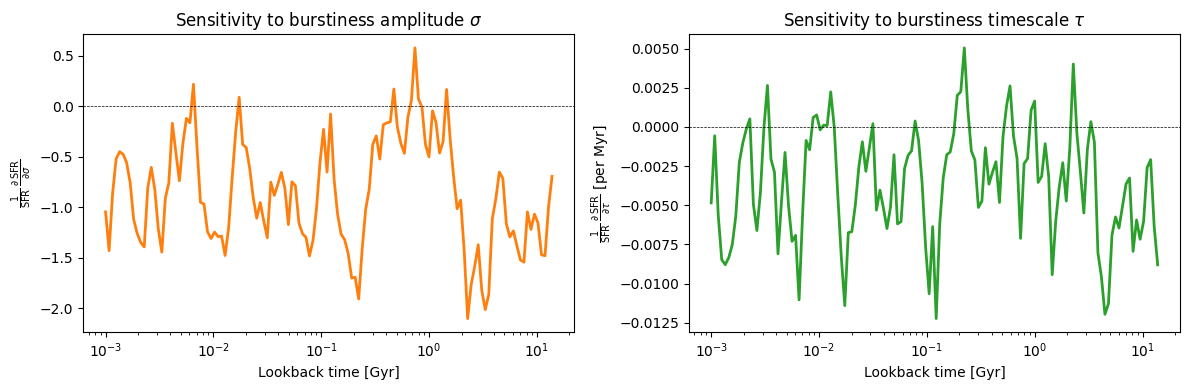

Gradients computed successfully — the full SFH model is end-to-end differentiable.


In [11]:
# --- Gradient demo: dSFR/d(sigma) and dSFR/d(tau) ---
key = jax.random.PRNGKey(42)
xi_fixed = jax.random.normal(key, (N_GRID,))
sfr_mean_fixed = double_powerlaw(ages_yr, alpha=1.5, beta=1.0, tau=5e9, norm=10.0)

def sfr_from_psd_params(sigma_ps, tau_ps):
    # Full SFH as a function of PSD parameters (with fixed xi).
    sqrt_p = compute_sqrt_power_drw(N_GRID, d_log_age, sigma_ps, tau_ps)
    gp_val = gp_from_xi(xi_fixed, sqrt_p, N_GRID)
    var = drw_variance(sigma_ps)
    return sfr_mean_fixed * jnp.exp(gp_val - 0.5 * var)

# Jacobian: dSFR/d(sigma) and dSFR/d(tau) at each grid point
sigma_0, tau_0 = 1.0, 50e6
jac_sigma = jax.jacfwd(lambda s: sfr_from_psd_params(s, tau_0))(sigma_0)
jac_tau = jax.jacfwd(lambda t: sfr_from_psd_params(sigma_0, t))(tau_0)

sfr_0 = sfr_from_psd_params(sigma_0, tau_0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Normalized sensitivity: (dSFR/dparam) / SFR
sens_sigma = jac_sigma / sfr_0
sens_tau = jac_tau / sfr_0 * 1e6  # per Myr for readability

ax1.plot(ages_gyr, sens_sigma, "C1", lw=2)
ax1.axhline(0, color="k", ls="--", lw=0.5)
ax1.set_xlabel("Lookback time [Gyr]")
ax1.set_ylabel("$\\frac{1}{\\mathrm{SFR}}\\,\\frac{\\partial\\,\\mathrm{SFR}}{\\partial\\sigma}$")
ax1.set_title("Sensitivity to burstiness amplitude $\\sigma$")
ax1.set_xscale("log")

ax2.plot(ages_gyr, sens_tau, "C2", lw=2)
ax2.axhline(0, color="k", ls="--", lw=0.5)
ax2.set_xlabel("Lookback time [Gyr]")
ax2.set_ylabel("$\\frac{1}{\\mathrm{SFR}}\\,\\frac{\\partial\\,\\mathrm{SFR}}{\\partial\\tau}$ [per Myr]")
ax2.set_title("Sensitivity to burstiness timescale $\\tau$")
ax2.set_xscale("log")

plt.tight_layout()
plt.show()

print("Gradients computed successfully — the full SFH model is end-to-end differentiable.")